In [ ]:
from google.colab import auth
auth.authenticate_user()
print("Autenticado correctamente")

Autenticado correctamente


In [ ]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "foodcom-bigdata"
client = bigquery.Client(project=PROJECT_ID)

q1 = """
SELECT RecipeCategory, COUNT(*) AS total_recetas, SUM(ReviewCount) AS total_resenas,
       ROUND(AVG(AggregatedRating), 2) AS calificacion_promedio
FROM `foodcom-bigdata.foodcom.recipes_clean`
GROUP BY RecipeCategory ORDER BY total_resenas DESC LIMIT 15
"""
df_q1 = client.query(q1).to_dataframe()

q2 = """
SELECT
  CASE
    WHEN ReviewCount = 0 THEN '0'
    WHEN ReviewCount BETWEEN 1 AND 5 THEN '1-5'
    WHEN ReviewCount BETWEEN 6 AND 20 THEN '6-20'
    WHEN ReviewCount BETWEEN 21 AND 100 THEN '21-100'
    ELSE '100+'
  END AS rango_resenas,
  COUNT(*) AS num_recetas, ROUND(AVG(AggregatedRating), 2) AS calificacion_promedio
FROM `foodcom-bigdata.foodcom.recipes_clean`
WHERE AggregatedRating IS NOT NULL
GROUP BY rango_resenas
ORDER BY CASE rango_resenas WHEN '0' THEN 0 WHEN '1-5' THEN 1 WHEN '6-20' THEN 2 WHEN '21-100' THEN 3 ELSE 4 END
"""
df_q2 = client.query(q2).to_dataframe()

q3 = """
SELECT r.RecipeCategory, COUNT(rv.ReviewId) AS total_reviews_reales,
       COUNT(DISTINCT rv.AuthorId) AS usuarios_unicos
FROM `foodcom-bigdata.foodcom.reviews_clean` rv
JOIN `foodcom-bigdata.foodcom.recipes_clean` r ON rv.RecipeId = r.RecipeId
GROUP BY r.RecipeCategory ORDER BY total_reviews_reales DESC LIMIT 15
"""
df_q3 = client.query(q3).to_dataframe()

print(df_q1.head())
print(df_q2)
print(df_q3.head())

  RecipeCategory  total_recetas  total_resenas  calificacion_promedio
0        Dessert          62072         143094                   4.60
1  One Dish Meal          31345         102911                   4.55
2   Lunch/Snacks          32586          97604                   4.66
3      Vegetable          27231          75296                   4.66
4      Breakfast          21101          61115                   4.64
  rango_resenas  num_recetas  calificacion_promedio
0           1-5       215956                   4.58
1          6-20        43436                   4.84
2        21-100         8809                   4.91
3          100+         1093                   4.94
  RecipeCategory  total_reviews_reales  usuarios_unicos
0        Dessert                139878            54158
1  One Dish Meal                 99910            39432
2   Lunch/Snacks                 95107            30717
3      Vegetable                 73518            23881
4      Breakfast                 59752  

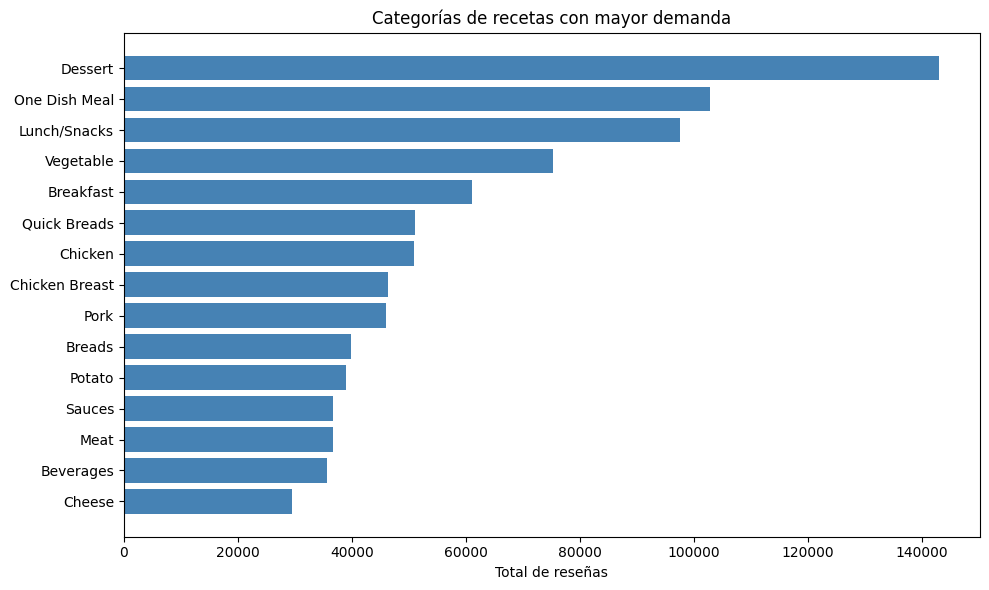

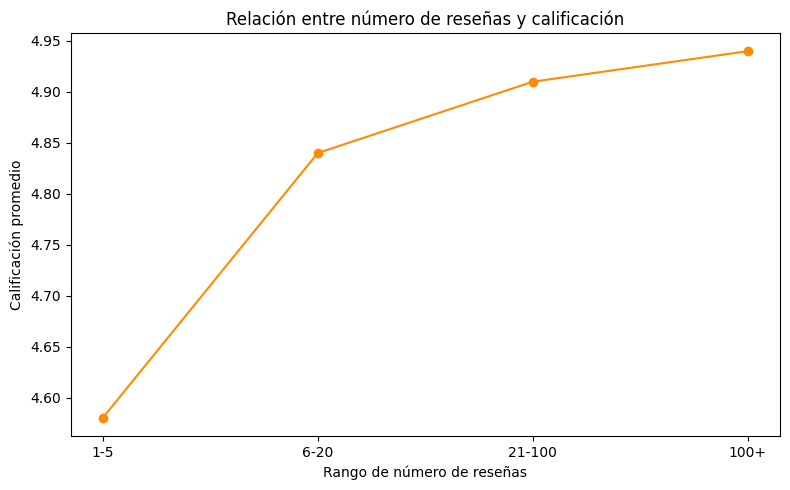

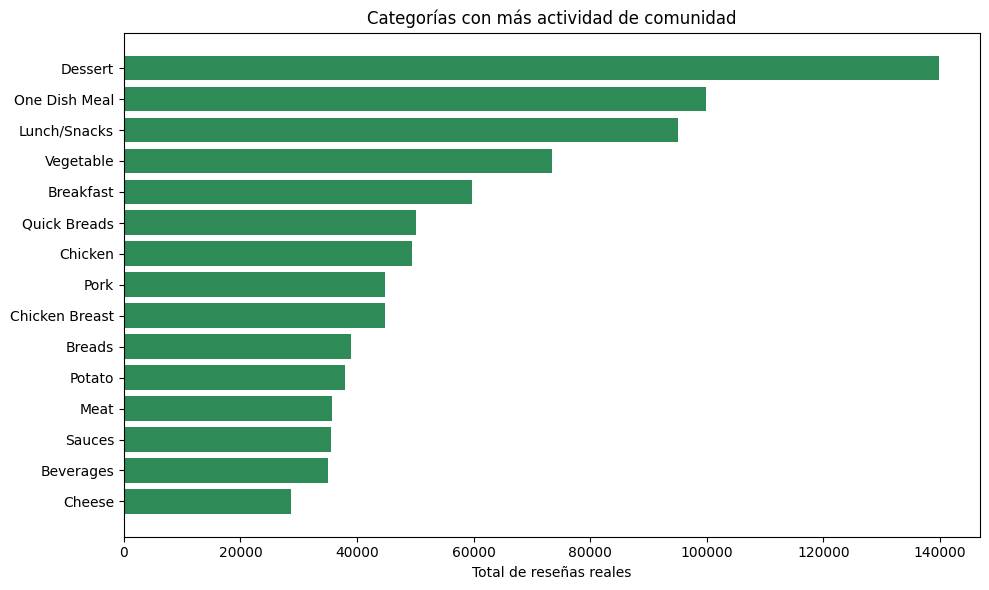

In [ ]:
import matplotlib.pyplot as plt

# Gráfica 1: Barras - Categorías con mayor demanda
plt.figure(figsize=(10,6))
plt.barh(df_q1['RecipeCategory'], df_q1['total_resenas'], color='steelblue')
plt.xlabel('Total de reseñas')
plt.title('Categorías de recetas con mayor demanda')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('q1_demanda.png')
plt.show()

# Gráfica 2: Líneas - Relación reseñas vs calificación
plt.figure(figsize=(8,5))
plt.plot(df_q2['rango_resenas'], df_q2['calificacion_promedio'], marker='o', color='darkorange')
plt.xlabel('Rango de número de reseñas')
plt.ylabel('Calificación promedio')
plt.title('Relación entre número de reseñas y calificación')
plt.tight_layout()
plt.savefig('q2_relacion.png')
plt.show()

# Gráfica 3: Barras - Categorías con más actividad de comunidad
plt.figure(figsize=(10,6))
plt.barh(df_q3['RecipeCategory'], df_q3['total_reviews_reales'], color='seagreen')
plt.xlabel('Total de reseñas reales')
plt.title('Categorías con más actividad de comunidad')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('q3_actividad.png')
plt.show()